<a href="https://colab.research.google.com/github/senisekoni32-a11y/ml_internship_tasks/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("churn_bigml_80.csv")

df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})
df["Churn"] = df["Churn"].astype(int)
df = pd.get_dummies(df, columns=["State", "Area code"], dtype=int)

X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ["Account length", "Number vmail messages", "Total day minutes", "Total day calls",
            "Total day charge", "Total eve minutes", "Total eve calls", "Total eve charge",
            "Total night minutes", "Total night calls", "Total night charge", "Total intl minutes",
            "Total intl calls", "Total intl charge", "Customer service calls"]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(X_train.shape, X_test.shape)
print(y.value_counts())

(2132, 71) (534, 71)
Churn
0    2278
1     388
Name: count, dtype: int64


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8408239700374532
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       456
           1       0.41      0.21      0.27        78

    accuracy                           0.84       534
   macro avg       0.64      0.58      0.59       534
weighted avg       0.81      0.84      0.82       534



In [8]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[433  23]
 [ 62  16]]


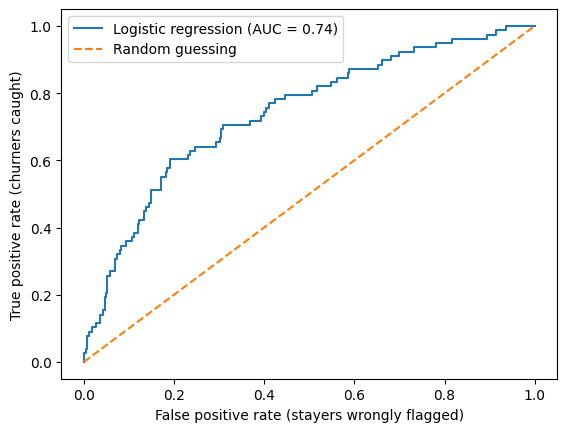

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]      # probability of churn for each test customer
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "--", label="Random guessing")
plt.xlabel("False positive rate (stayers wrongly flagged)")
plt.ylabel("True positive rate (churners caught)")
plt.legend()
plt.show()

In [10]:
import numpy as np

coef = pd.Series(model.coef_[0], index=X_train.columns)
result = pd.DataFrame({"coefficient": coef, "odds_ratio": np.exp(coef)})
result.sort_values("odds_ratio", ascending=False).head(8)

,coefficient,odds_ratio
International plan,2.375898,10.760672
State_TX,1.361923,3.903691
State_MT,0.957950,2.606349
State_MI,0.815350,2.259967
State_NJ,0.807122,2.241449
Customer service calls,0.792720,2.209397
State_MS,0.773485,2.167305
State_SC,0.760266,2.138845


## Results

This task introduced me to logistic regression, a model that predicts a yes/no outcome. Here it predicts whether a telecom customer will churn (leave), using the customer data I preprocessed earlier.

Only about 15% of customers churn, so accuracy alone is misleading. The model scored 84.1%, which is actually lower than the 85.4% I would get by guessing "stays" for every customer. The classification report shows why: recall for churners was only 0.21 (it caught about 16 of 78 churners), and precision was 0.41. The ROC curve gave an AUC of 0.74, so the model separates churners from stayers better than chance, but only moderately well.

The odds ratios show what drives churn. Customers with an international plan have about 10.8 times the odds of churning, and each extra standard deviation of customer service calls (roughly two calls) about doubles the odds (2.2). Having a voice mail plan lowers the odds (0.37).

Limitations: the numeric columns were scaled, so those odds ratios are per standard deviation. Day minutes and day charge carry almost the same information, so their coefficients shouldn't be read separately. The individual state coefficients are based on few customers each and are probably noise. All of these show patterns in the data, not cause and effect.